# **Lab Exercise: Linear and Logistic Regression**

## **Linear Regression Construction** 

#### **Section 1: Setting Up and Importing Libraries**
*Objective:* Load the required `Python libraries`.


In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### **Section 2: Linear Regression Data Preparation**

*Objective:* Create a dataset for linear regression.

Task: Write the code to:

Create a dataset with features and target variables for linear regression.
Visualize the data using Matplotlib.


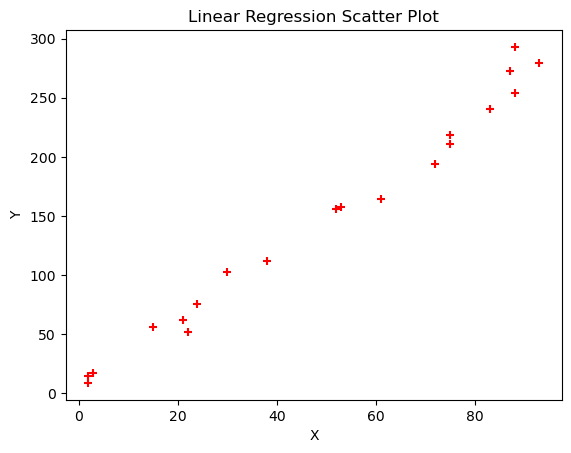

In [180]:
# Generate synthetic data for linear regression
np.random.seed(42)  # For reproducibility
X = np.random.randint(1, 100, 20)  # Features (independent variable)
y = 3 * X + 7 + np.random.normal(0, 15, 20)  # Target with noise

# Visualize the data

# You need to use scatter chart to Visualize the input dataset X & y
# Your chart need to label the x-axis, y-axis and title
# Your chart should use grid

# Your code
%matplotlib inline
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Scatter Plot')
plt.scatter(X,y,color='red',marker='+')
plt.show()


#### **Section 3: Implementing Linear Regression**

*Objective:* Practice linear regression construction.

Task: Write the code to:

Write a Linear Regression function to minimize the cost function and find the optimal parameters.


For **Undergraduate students** (CS457): You can **choose** any of the following methods to implement it.
1. You can use any scikit-learn library.
2. Manually write cost function & gradient descent function to implement it.

For **Graduate students** (CS557): You have to implement it by
1. Manually write cost function & gradient descent function to implement it.


In [183]:
# Your code for linear regression model

# Sklearn model
from sklearn import linear_model

# Prepare data
print (X)
print (y)
x_train = X.reshape(-1,1)
y_train = y

# Building the Model
reg = linear_model.LinearRegression()
reg.fit(x_train,y_train)
# Review Model parameter 

[52 93 15 72 61 21 83 87 75 75 88 24  3 22 53  2 88 30 38  2]
[156.04873461 279.0140537   55.62943407 194.30079633 164.12623251
  61.56568706 240.80753319 272.71370999 218.37963887 210.81544448
 292.98473153  75.61335549  17.01292307  51.62877721 157.83425913
  14.66383885 253.73509634 102.63547028 111.99041965   8.62459375]


LinearRegression()

In [185]:
# Your code for linear regression model

# Manually write cost function & gradient descent 

# Reshape X to include a bias term (column of ones for the intercept) by np.column_stack
X=np.column_stack((np.ones(len(X)), X/1000))
y = y/1000

# Define the cost function for linear regression
def compute_cost(X, y, theta):
    """
    Compute the cost function for linear regression.
    """
    # your code 
    cost = np.sum(np.square(np.dot(X, theta) - y)) / (2 * len(y))

    return cost
    
   

# Define the gradient descent function
def gradient_descent(X, y, alpha, iterations):
    """
    Perform gradient descent to minimize the cost function.
    """
    
    theta = np.zeros(2)  # Initialize theta (matching number of features)
    m = len(y)  # Number of training examples

    

    # Iterate to update theta with iterations
    # your code 
    for i in range(iterations):
        # Update theta[0] (intercept term) using the gradient of the cost function
        t0 = theta[0] - (alpha / m) * np.sum(np.dot(X, theta) - y)
        
        # Update theta[1] (slope term) using the gradient of the cost function
        t1 = theta[1] - (alpha / m) * np.sum((np.dot(X, theta) - y) * X[:, 1])
        
        # Update theta as a new array with the computed values
        theta = np.array([t0, t1])

    return theta
    


# Number of iterations for gradient descent
iterations = 5000

# Learning rate for gradient descent
alpha = 0.0001

# Call the gradient descent function to compute optimized parameters
theta = gradient_descent(X,y,alpha,iterations)

# Compute the cost using the optimized parameters
cost = compute_cost(X,y,theta)

# Print the results
print("Optimized theta (parameters):", theta)  # Optimized values for theta (intercept and slope)
print("Final cost:", cost)  # Final cost value to evaluate the fit

Optimized theta (parameters): [0.05779733 0.00429999]
Final cost: 0.008278320744661973


### **Section 4: Visualizing the Linear Regression Line**

*Objective:* Plot the regression line with the original data.

Task: Plot the data points and the fitted regression line.

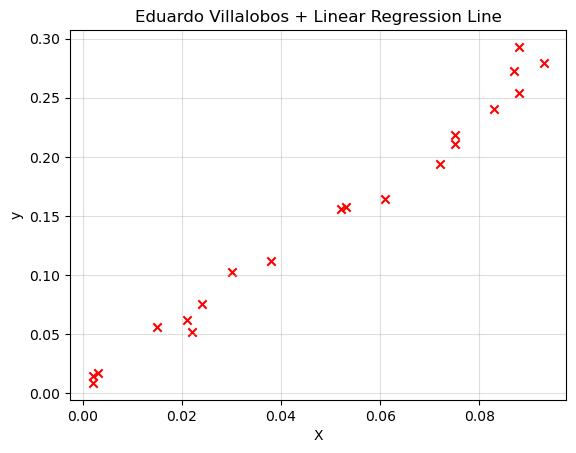

In [188]:
# Compare predictions with actual values
y_pred = np.dot(X, theta)
# Plot the data and regression line
# You need to use scatter chart to Visualize the input dataset X & y
# Your chart should plot the regression line using theta_optimal predictions 
# Your chart need to label the x-axis, y-axis and title
# Your chart should use grid
# Please add your name to the graph title
test = X[:, 1]
# Your code: 
plt.scatter(test,y,marker='x',color='red')
samples = np.linspace(np.min(test),np.max(test))
#plt.plot(samples,theta[0] + theta[1]*samples,color='blue')
#could not get the line to print out correctly

plt.title('Eduardo Villalobos + Linear Regression Line')
plt.xlabel('X')
plt.ylabel('y')
plt.grid(alpha=0.4)
plt.show()


## **Logistic Regression Construction** 

#### **Section 1: Logistic Regression Data Preparation**

*Objective:* Prepare data for logistic regression.

Task: Write the code to:

Create synthetic data for binary classification.
Visualize the data.

#### Dataset Description

Study_hour_Data.csv - The dataset simulates a scenario where students' chances of passing a course are influenced by their study habits and class participation. It contains 200 observations and the following three columns:


**Hours of Study:**
Integer values representing the number of hours a student spends studying in a week.
Range: 0 to 9.

**Class Participation:**
Float values between 0 and 1, representing the level of engagement in class activities.
Higher values indicate greater participation.

**Passed:**
Binary target variable indicating whether the student passed the course:
1: Passed.
0: Did not pass.
Determined based on a weighted combination of Hours of Study and Class Participation (with added noise), with a threshold value of 5.

In [211]:
import pandas as pd
#read data from Pandas 
df = pd.read_csv('Study_hour_Data.csv')
# Load dataset
# please use Study_hour_Data.csv as your target data
data = df

# Display basic information
print(data.info())
print(data.describe())

#Generate your training data X & y
X =  df[['Hours of Study']].values
y =  df.Passed.values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Hours of Study       200 non-null    int64  
 1   Class Participation  200 non-null    float64
 2   Passed               200 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 4.8 KB
None
       Hours of Study  Class Participation      Passed
count      200.000000           200.000000  200.000000
mean         4.115000             0.505828    0.750000
std          2.751295             0.289315    0.434099
min          0.000000             0.009934    0.000000
25%          2.000000             0.248919    0.750000
50%          4.000000             0.492630    1.000000
75%          6.000000             0.771555    1.000000
max          9.000000             0.992191    1.000000


#### **Section 2: Visualize the data**

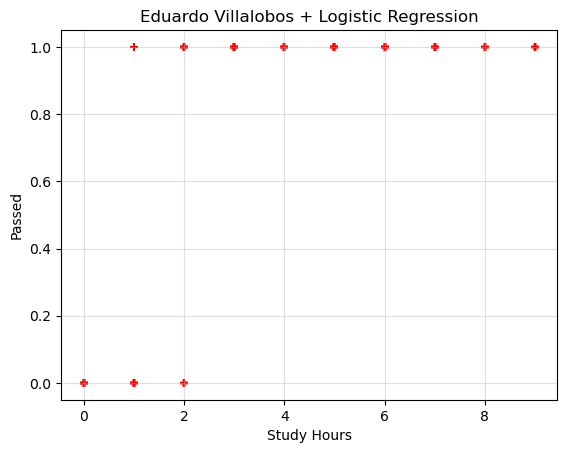

In [214]:
# Visualize the data

# You need to use scatter chart to Visualize the input dataset X & y
# Your chart need to label the x-axis, y-axis and title
# Your chart should use grid
# Please add your name to the graph title

# Your code: 
plt.scatter(X,y,marker='+',color='red')
plt.xlabel('Study Hours')
plt.ylabel('Passed')
plt.grid(alpha=0.4)
plt.title("Eduardo Villalobos + Logistic Regression")
plt.show()


#### **Section 3: Implementing Logistic Regression**

*Objective:* Implement logistic regression.

For **Undergraduate students** (CS457): You can **choose** any of the following methods to implement it.
1. You can use any scikit-learn library.
2. Manually write cost function & gradient descent function to implement it. 

For **Graduate students** (CS557): You have to implement it by
1. Manually write cost function & gradient descent function to implement it.


Then, use the scipy.optimize library to fit the logistic regression model.

In [217]:
# Your code for logistic regression model

# Sklearn model
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression

# Prepare data
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8)
# Building the Model
model = LogisticRegression()
# Review Model parameter 

In [241]:
# Your logistic regression model
model.fit(X_train, y_train)
# Define the sigmoid function
def sigmoid(z):
    return 1 / (1+np.exp(-z))
    
     

# Define the cost function for logistic regression
def cost_function(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    cost = -(1 / m) * (y.dot(np.log(h)) + (1 - y).dot(np.log(1 - h)))
    return cost

# Define the gradient function
def gradient(theta, X, y):
    """
    Computes the gradient of the cost function with respect to the model parameters.
    
    Parameters:
    theta: ndarray
        Model parameters (weights), a 1D array.
    X: ndarray
        Feature matrix where rows are samples and columns are features.
    y: ndarray
        Target values, a 1D array of binary labels (0 or 1).

    Returns:
    ndarray
        Gradient vector, indicating the direction and magnitude of change for each parameter.
    """
    
    m = len(y)  # Number of training examples
    h = sigmoid(X.dot(theta))  # Predicted probabilities using the sigmoid function
    gradient = (1 / m) * X.T.dot(h - y)  # Compute the gradient vector

    return gradient
    

In [243]:
# Train your model
from scipy.optimize import minimize

def train(X, y):

    # Reshape X to include a bias term (intercept)
    X = np.column_stack((np.ones(len(X)), X))  # Adds a column of 1s for the intercept
    
    # Initialize theta (parameters) as a zero vector with the same number of features as X
    theta = np.zeros(X.shape[1])
    
    # Minimize the cost function using scipy.optimize.minimize
    # - fun: The cost function to minimize
    # - x0: Initial guess for theta (parameters)
    # - args: Additional arguments passed to the cost function (X and y)
    # - method: Optimization algorithm ("TNC" in this case)
    # - jac: The gradient function used for optimization
    result = minimize(fun=cost_function, x0=theta, args=(X, y), method='TNC', jac=gradient, options = {'maxfun': 4000})
    
    
    return result     
theta = train(X_train,y_train)

theta_optimized = theta.x


# Print the optimized parameters (theta)
print("Optimized theta (parameters):", theta_optimized)

Optimized theta (parameters): [-6.80041671  3.59870623]


#### **Section 4: Evaluate the model**

*Objective:* Evaluate the model with the fitted data.

Task: build the Predict function, and Calculate accuracy.

In [246]:
# Predict function
def predict(X, theta):
    probabilities = sigmoid(X.dot(theta))
    return (probabilities >= 0.5).astype(int)

# Make predictions
X_test_C = np.column_stack((np.ones(len(X_test)), X_test))
predictions = predict(X_test_C, theta_optimized)

In [250]:
# Calculate accuracy
accuracy = np.mean(predictions == y_test) * 100
print("Accuracy:", accuracy, "%")

Accuracy: 95.0 %


### **Section 5: Visualizing Logistic Regression Fit**

*Objective:* Plot the logistic regression fit with the original data.

Task: Plot the sigmoid curve over the range of input features.

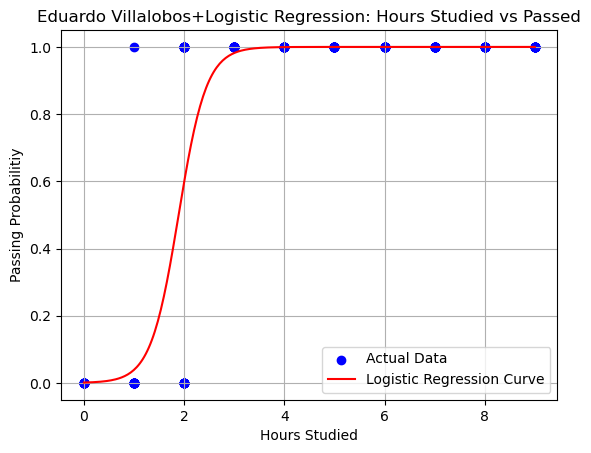

In [257]:
# Plot the data and regression line
# You need to use scatter chart to Visualize the input dataset X & y
# Your chart should plot the regression line using theta_optimal predictions 
# Your chart need to label the x-axis, y-axis and title
# Your chart should use grid
# Please add your name to the graph title

plt.scatter(X,y,color='blue',label='Actual Data')

hours_range = np.linspace(X.min(),X.max(),300).reshape(-1,1)
X_range = np.column_stack((np.ones(len(hours_range)), hours_range))

probabilities = sigmoid(X_range.dot(theta_optimized))

plt.plot(hours_range,probabilities,color='red',label='Logistic Regression Curve')

plt.xlabel('Hours Studied')
plt.ylabel('Passing Probabilitiy')
plt.title('Eduardo Villalobos+Logistic Regression: Hours Studied vs Passed')
plt.legend()
plt.grid()
plt.show()